# Plotting with Marsilea

[Marsilea](https://github.com/Marsilea-viz/marsilea) builds a figure from separate plots
that you place yourself, instead of one function call with many arguments.

It can read from an {class}`~anndata.AnnData` directly, so you don't pull arrays out by hand.

This page needs anndata 0.13 or newer and [statannotations](https://github.com/trevismd/statannotations) for the significance tests.

Let's first load the PBMC dataset.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd

import scanpy as sc

pbmc = sc.datasets.pbmc3k_processed().raw.to_adata()
pbmc

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    obsp: 'distances', 'connectivities'
    layers: None (.X)

Define the cells and markers that we want to draw.

In [2]:
cell_markers = {
    "CD4 T cells": ["IL7R"],
    "CD14+ Monocytes": ["CD14", "LYZ"],
    "B cells": ["MS4A1"],
    "CD8 T cells": ["CD8A"],
    "NK cells": ["GNLY", "NKG7"],
    "FCGR3A+ Monocytes": ["FCGR3A", "MS4A7"],
    "Dendritic cells": ["FCER1A", "CST3"],
    "Megakaryocytes": ["PPBP"],
}

cells, markers = [], []
for c, ms in cell_markers.items():
    cells += [c] * len(ms)
    markers += ms

uni_cells = list(cell_markers.keys())
cell_colors = [
    "#568564",
    "#DC6B19",
    "#F72464",
    "#005585",
    "#9876DE",
    "#405559",
    "#58DADA",
    "#F85959",
]
cmapper = dict(zip(uni_cells, cell_colors, strict=True))

Import Marsilea, and `A`, the accessor that names parts of an `AnnData`.

In [3]:
import marsilea as ma
import marsilea.plotter as mp
from anndata.acc import A

## Heatmap

The smallest example, a heatmap and nothing else. `height` and `width` set the size of the
main plot in inches.

Marsilea takes any array, so you can always pass a matrix you built yourself:

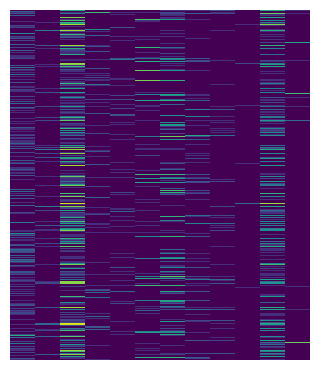

In [4]:
exp = pbmc[:, markers].X.toarray()

m = ma.Heatmap(exp, cmap="viridis", height=3.5, width=3)
m.render();

But `exp` is a copy of `pbmc`, and you need to copy more from `pbmc` to add more components to the heatmap. To simplify the syntax, pass the `anndata` object instead, and name what you want with `A`.

`A.X[:, markers]` is one reference per gene, stacked into a matrix. No subsetting, no
`.toarray()`.

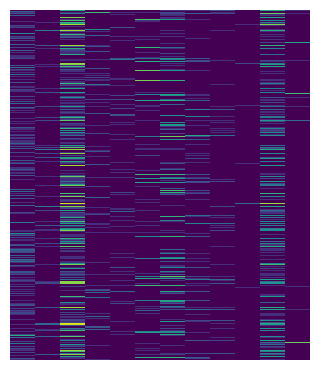

In [5]:
m = ma.Heatmap(pbmc, A.X[:, markers], cmap="viridis", height=3.5, width=3)
m.render();

To match the scanpy heatmap, first split it by cell type.

We use `group_rows` to split the heatmap by categorical group labels `louvain`.

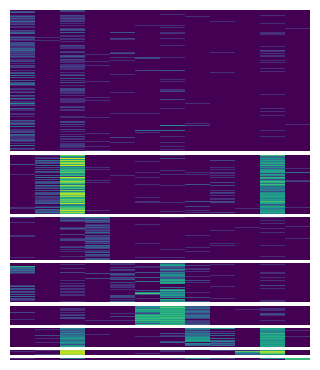

In [6]:
m.group_rows(A.obs["louvain"])
m.render();

Now let's label the cell types and the marker names.

`add_left`, `add_top` and the other `add_*` methods attach a plot to one side of the main
plot. Such a plot is called a plotter; there are many plotters in Marsilea. `size` and `pad` set how much room it gets and how
far it sits from its neighbor.

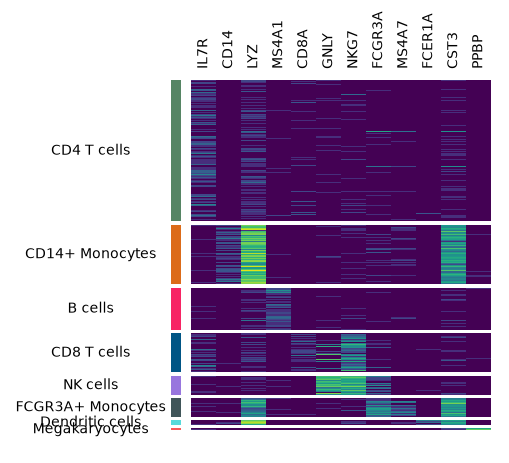

In [7]:
# Create plotters
chunk = mp.Chunk(uni_cells, rotation=0, align="center")
colors = mp.Colors(A.obs["louvain"], palette=cmapper)
label_markers = mp.Labels(markers)

# Add to the heatmap
m.add_left(colors, size=0.1, pad=0.1)
m.add_left(chunk)
m.add_top(label_markers, pad=0.1)
m.render();

A dendrogram shows how similar the cell types are. Use `add_dendrogram` and add it to the right.

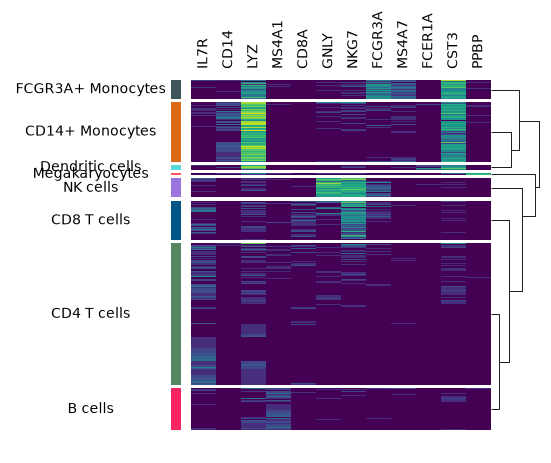

In [8]:
m.add_dendrogram("right", add_base=False)
m.render();

`add_legends` collects every legend at once and lays them out for you. `add_title` adds a
title.

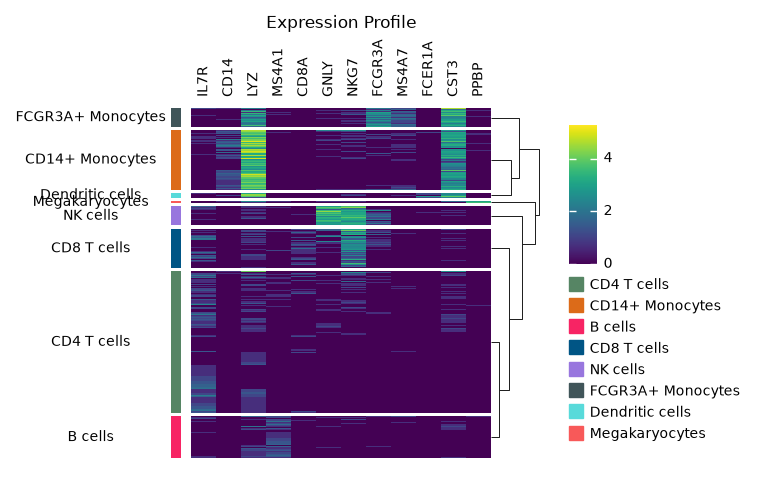

In [9]:
m.add_legends()
m.add_title("Expression Profile")
m.render();

The whole thing in one place. Three things to remember:

- Always call `render()` last, or nothing is drawn.
- The order of `add_*` calls sets the order of the plotters.
- `group_rows` and `group_cols` can be called at any point.

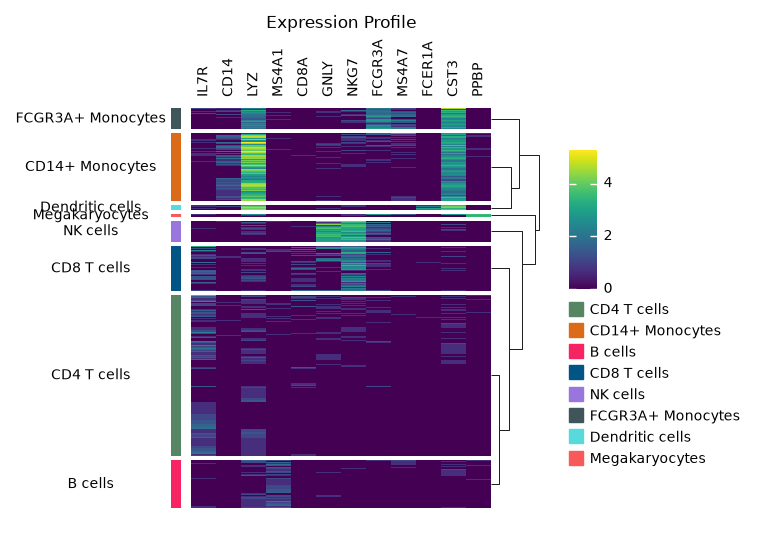

In [10]:
m = ma.Heatmap(pbmc, A.X[:, markers], cmap="viridis", height=4, width=3)
m.group_rows(A.obs["louvain"])

m.add_left(mp.Colors(A.obs["louvain"], palette=cmapper), size=0.1, pad=0.1)
m.add_left(mp.Chunk(uni_cells, rotation=0, align="center"))
m.add_top(mp.Labels(markers), pad=0.1)
m.add_dendrogram("right", add_base=False)

m.add_legends()
m.add_title("Expression Profile")
m.render();

That covers the basics. The same pieces can rebuild plots scanpy already has.

The next few plots summarise cell types rather than cells, so aggregate first.
{func}`~scanpy.get.aggregate` takes a reference for `by`, and writes the group sizes to
`n_obs_aggregated` so you do not have to count them.

Two more things go in here: the fraction of cells expressing each gene, drawn by the dot
plot as dot size, and the lineage of each cell type, used by the significance section.

In [11]:
lineages = {
    "CD4 T cells": "Lymphoid",
    "CD14+ Monocytes": "Myeloid",
    "B cells": "Lymphoid",
    "CD8 T cells": "Lymphoid",
    "NK cells": "Lymphoid",
    "FCGR3A+ Monocytes": "Myeloid",
    "Dendritic cells": "Myeloid",
    "Megakaryocytes": "Myeloid",
}

agg = sc.get.aggregate(
    pbmc[:, markers], by=A.obs["louvain"], func=["mean", "count_nonzero"]
)
agg.layers["fraction"] = (
    agg.layers["count_nonzero"] / agg.obs["n_obs_aggregated"].to_numpy()[:, np.newaxis]
)
agg.obs["lineage"] = pd.Categorical(
    [lineages[c] for c in agg.obs["louvain"]], categories=["Lymphoid", "Myeloid"]
)
agg

AnnData object with n_obs × n_vars = 8 × 12
    obs: 'louvain', 'n_obs_aggregated', 'lineage'
    var: 'n_cells'
    layers: 'mean', 'count_nonzero', 'fraction'

## Matrixplot

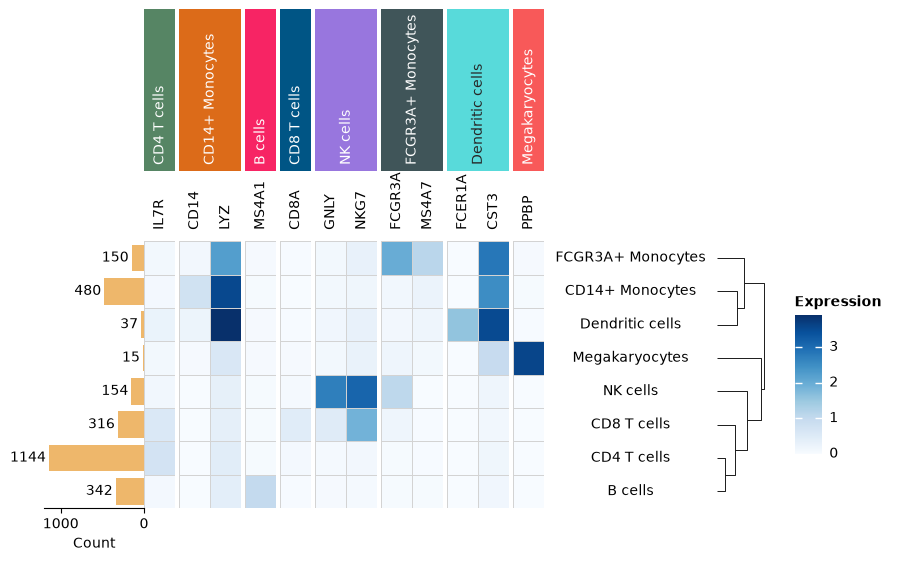

In [12]:
h, w = agg.shape

m = ma.Heatmap(
    agg,
    A.layers["mean"][:, :],
    height=h / 3,
    width=w / 3,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)
m.add_right(mp.Labels(A.obs.index, align="center"), pad=0.1)
m.add_top(mp.Labels(A.var.index), pad=0.1)
# Use 'order=' to control the order of groups
m.group_cols(cells, order=uni_cells)
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
m.add_left(mp.Numbers(A.obs["n_obs_aggregated"], color="#EEB76B", label="Count"))
m.add_dendrogram("right", pad=0.1)
m.add_legends()
m.render();

## Dot plot

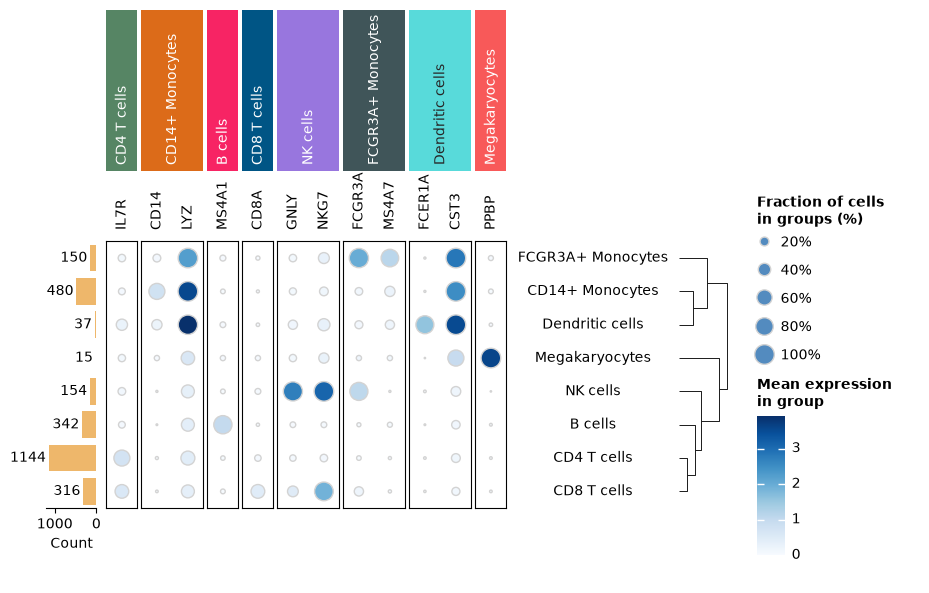

In [13]:
m = ma.SizedHeatmap(
    agg,
    A.layers["fraction"][:, :],
    A.layers["mean"][:, :],
    cluster_data=A.layers["fraction"][:, :],
    height=h / 3,
    width=w / 3,
    edgecolor="lightgray",
    cmap="Blues",
    size_legend_kws=dict(
        colors="#538bbf",
        title="Fraction of cells\nin groups (%)",
        labels=["20%", "40%", "60%", "80%", "100%"],
        show_at=[0.2, 0.4, 0.6, 0.8, 1.0],
    ),
    color_legend_kws=dict(title="Mean expression\nin group"),
)

m.add_top(mp.Labels(A.var.index), pad=0.1)
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
m.group_cols(cells, order=uni_cells)

m.add_right(mp.Labels(A.obs.index, align="center"), pad=0.1)
m.add_left(
    mp.Numbers(A.obs["n_obs_aggregated"], color="#EEB76B", label="Count"),
    size=0.5,
    pad=0.1,
)
m.add_dendrogram("right", pad=0.1)
m.add_legends()
m.render();

## Combining plots: Dot plot + Heatmap

You may want to combine multiple plots in one figure. `+` puts two boards side by side, `/` stacks them, and `add_legends` on the result gathers the legends from both.

Here we show an example of a dot plot sitting next to per-cell-type QC.

In [14]:
from scipy.cluster.hierarchy import linkage

qc_metrics = ["n_genes", "percent_mito", "n_counts"]
qc = pbmc.obs.groupby("louvain", observed=True)[qc_metrics].mean()
agg.obsm["qc"] = ((qc - qc.mean()) / qc.std()).to_numpy()

Each plot clusters its own data, so the two would order their rows differently and stop
lining up. We need to compute the linkage once and pass it to both, and only one needs to draw the dendrogram.

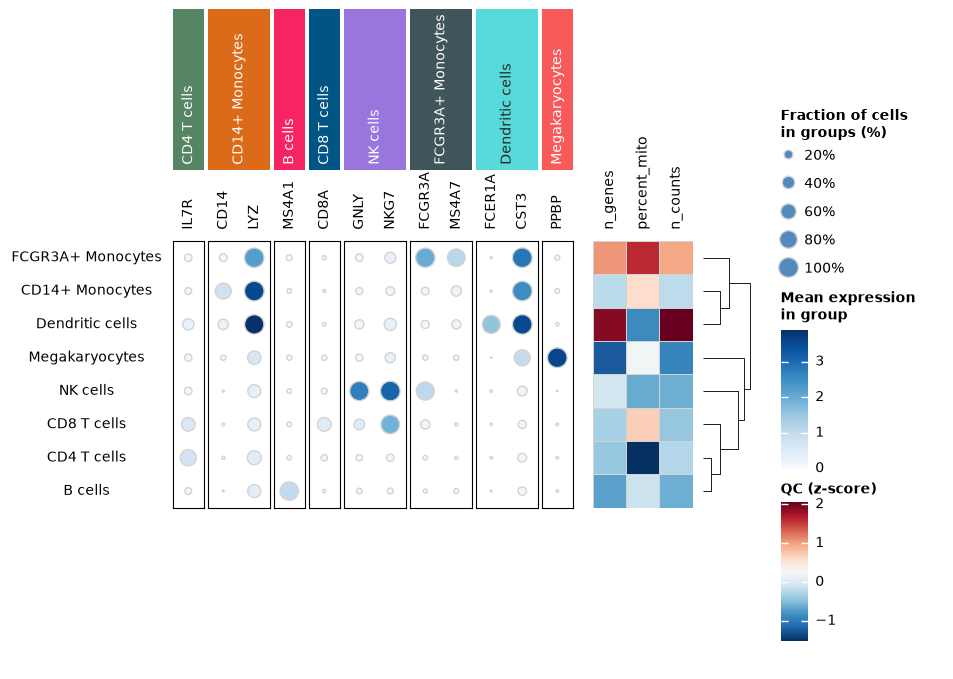

In [15]:
row_linkage = linkage(agg.layers["mean"], method="average")

dots = ma.SizedHeatmap(
    agg,
    A.layers["fraction"][:, :],
    A.layers["mean"][:, :],
    height=h / 3,
    width=w / 3,
    edgecolor="lightgray",
    cmap="Blues",
    size_legend_kws=dict(
        colors="#538bbf",
        title="Fraction of cells\nin groups (%)",
        labels=["20%", "40%", "60%", "80%", "100%"],
        show_at=[0.2, 0.4, 0.6, 0.8, 1.0],
    ),
    color_legend_kws=dict(title="Mean expression\nin group"),
)
dots.add_left(mp.Labels(A.obs.index, align="center"), pad=0.1)
dots.add_top(mp.Labels(A.var.index), pad=0.1)
dots.group_cols(cells, order=uni_cells)
dots.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
dots.add_dendrogram("left", linkage=row_linkage, show=False)

qc_panel = ma.Heatmap(
    agg,
    [A.obsm["qc"][:, i] for i in range(len(qc_metrics))],
    height=h / 3,
    width=len(qc_metrics) / 3,
    cmap="RdBu_r",
    linewidth=0.5,
    linecolor="lightgray",
    label="QC (z-score)",
)
qc_panel.add_top(mp.Labels(qc_metrics), pad=0.1)
qc_panel.add_dendrogram("right", linkage=row_linkage, pad=0.1)

# 0.2 is the padding between the two plots
comp = dots + 0.2 + qc_panel
comp.add_legends()
comp.render();

## Significance annotation

Every seaborn-backed plotter can test pairs of categories and draw the result: `Bar`,
`Box`, `Boxen`, `Violin`, `Point`, `Strip` and `Swarm`. The tests come from
[statannotations](https://github.com/trevismd/statannotations).

These plotters read wide data, one column per category. Cell types have different sizes, so
the short columns need `NaN` padding. Marsilea drops that padding before testing, and warns
if a bracket ends up with no label.

In [16]:
def by_cell_type(gene):
    """Expression of one gene, one column per cell type, NaN-padded to equal length."""
    values = pbmc[:, gene].X.toarray().ravel()
    louvain = pbmc.obs["louvain"]
    return pd.DataFrame({
        cell_type: pd.Series(values[(louvain == cell_type).to_numpy()])
        for cell_type in louvain.cat.categories
    })


by_cell_type("LYZ").iloc[:4]

,CD4 T cells,CD14+ Monocytes,B cells,CD8 T cells,NK cells,FCGR3A+ Monocytes,Dendritic cells,Megakaryocytes
0,0.693147,3.218876,1.386294,0.693147,0.000000,1.386294,3.951244,0.000000
1,1.098612,4.025352,0.693147,0.693147,0.000000,1.791759,4.532599,2.484907
2,0.000000,3.871201,0.693147,0.693147,0.693147,2.639057,3.761200,2.397895
3,0.000000,4.158883,0.693147,0.000000,0.000000,2.397895,4.634729,0.000000


We use `annotate_stats` to add significance annotations. `pairs="all"` compares every pair. `ref=` keeps only the ones against a single category.

The correction is done across every bracket at once, not once per group.

Instead of transposing the adata, we can simply set `obs_axis="col"` to put the observations on the columns and genes on the rows.

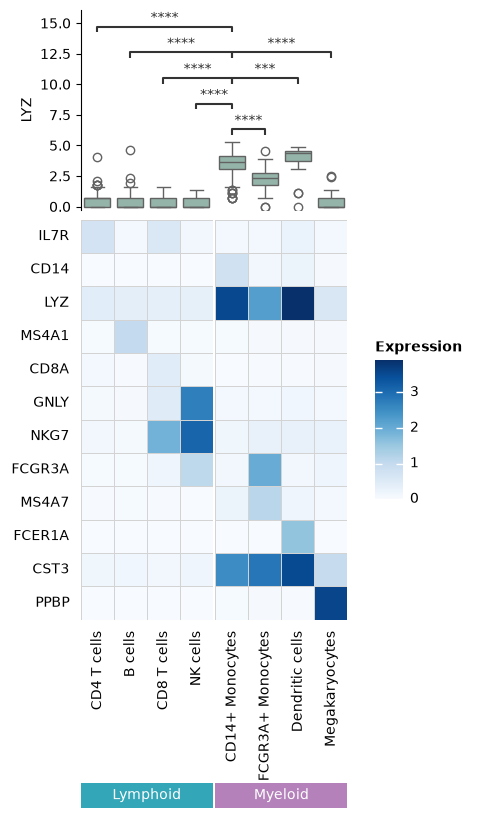

In [17]:
lyz = mp.Box(by_cell_type("LYZ"), color="#8FB9AA", label="LYZ")
lyz.annotate_stats(
    pairs="all",
    ref="CD14+ Monocytes",
    test="Mann-Whitney",
    text_format="star",
    comparisons_correction="Benjamini-Hochberg",
)

m = ma.Heatmap(
    agg,
    A.layers["mean"][:, :],
    obs_axis="col",
    height=w / 3,
    width=h / 3,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)
m.group_cols(A.obs["lineage"])
m.add_top(lyz, size=2, pad=0.1)
m.add_left(mp.Labels(A.var.index), pad=0.1)
m.add_bottom(mp.Labels(A.obs.index), pad=0.1)
m.add_bottom(mp.Chunk(["Lymphoid", "Myeloid"], ["#33A6B8", "#B481BB"]))
m.add_legends()
m.render();

<div class="alert alert-warning" role="alert">
One caveat: This test here is only for demonstration purposes. It treats every cell as an independent sample, and with a few thousand cells almost anything clears any threshold, so the stars track sample size more than effect size. If you already have p-values from differential expression analysis, pass them with `pvalues=` for Marsilea to draw instead of running a test.
</div>

## Tracksplot

A tracksplot has no main heatmap. It is a stack of side plots on a shared axis, which you
can start with `height=0` and `init_main=False`. Grouping, clustering and `add_*` still work.

Each track is one gene across all cells. Use `A.X[:, gene]` as a single reference, and
`label=` to name it.

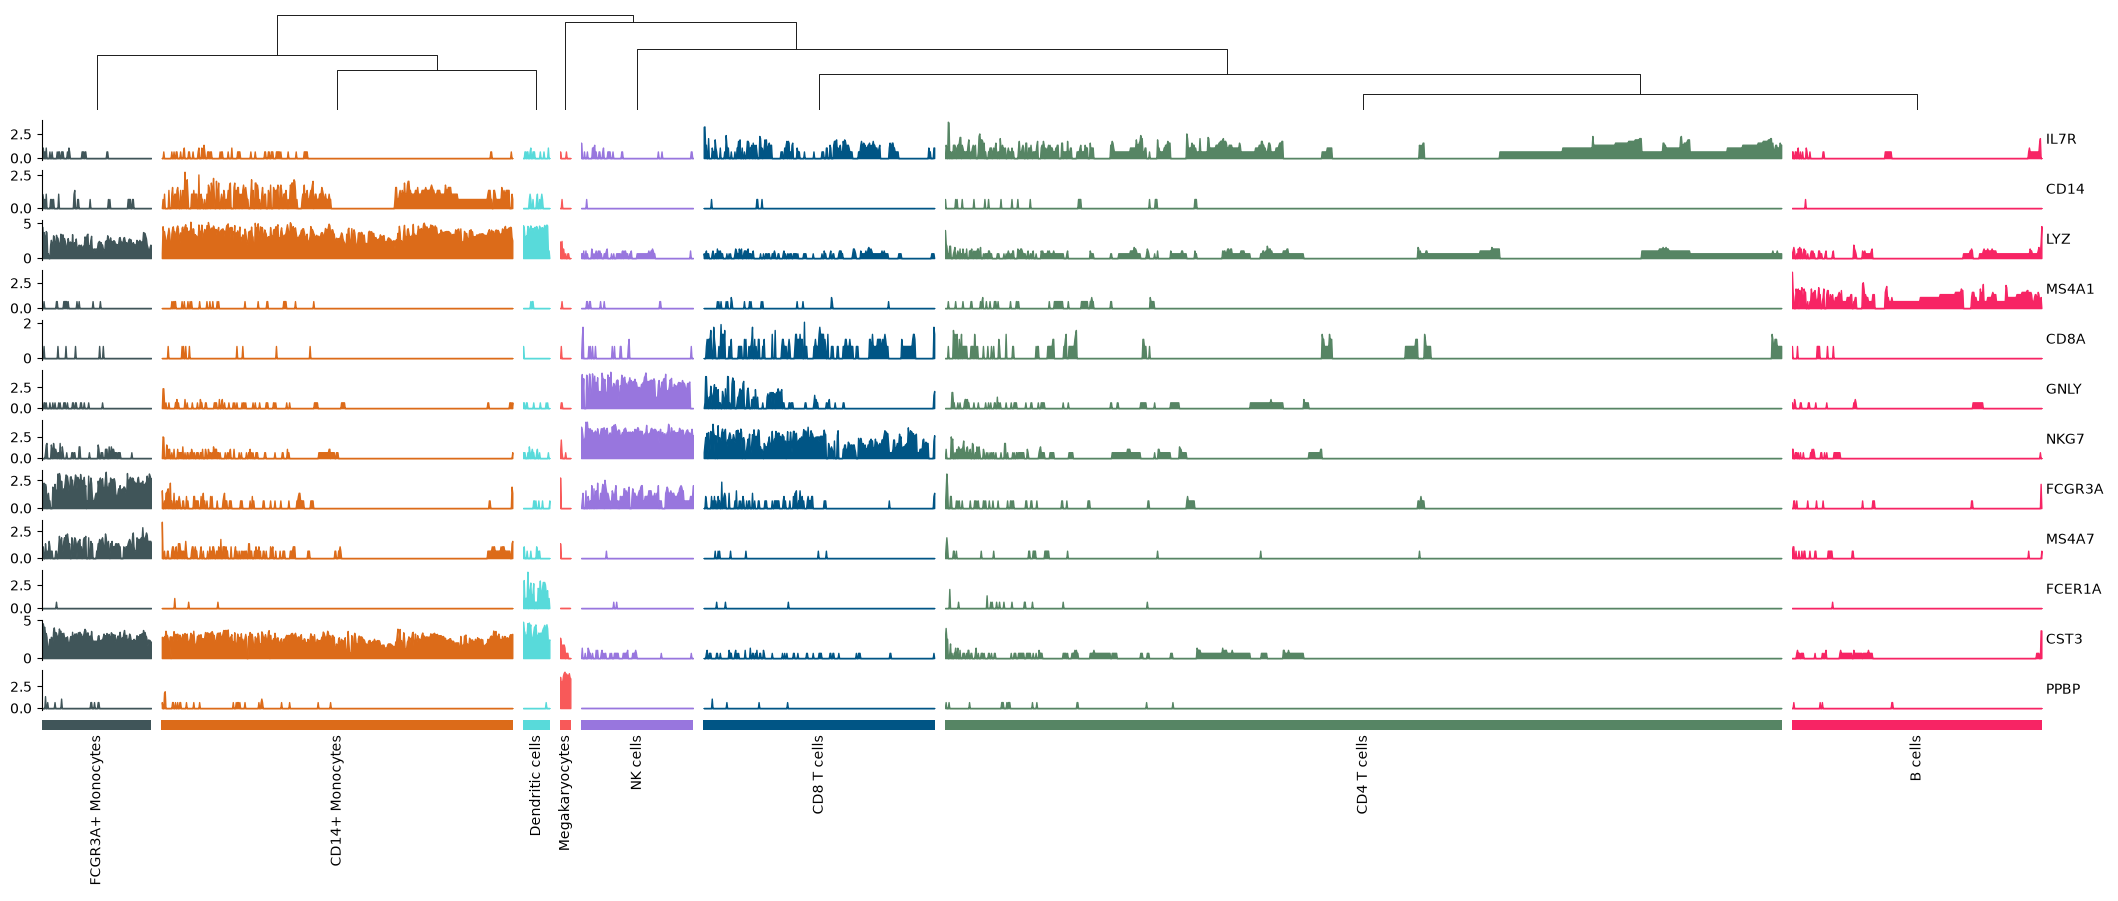

In [18]:
tp = ma.ClusterBoard(
    pbmc, A.X[:, markers], obs_axis="col", width=20, height=0, init_main=False
)

tp.group_cols(A.obs["louvain"], spacing=0.005)
tp.add_dendrogram("top", add_base=False, size=1)
for gene in markers:
    tp.add_bottom(
        mp.Area(
            A.X[:, gene],
            add_outline=False,
            alpha=1,
            group_kws={"color": cell_colors},
            label=gene,
            label_loc="right",
        ),
        size=0.4,
        pad=0.1,
    )
tp.add_bottom(mp.Colors(A.obs["louvain"], palette=cmapper), size=0.1, pad=0.1)
tp.add_bottom(mp.Chunk(uni_cells, rotation=90))
tp.render();

## Stacked Violin

Same board as the tracksplot, one violin per gene, named by the same `label=` and
`label_loc=`.

Like `sc.pl.stacked_violin`, each violin is colored by its cell type's median. That color
comes from a `ScalarMappable`, not from the plotter, so no plotter can draw a legend for
it. `custom_legend` takes a function returning a legend artist and adds it to the rest.

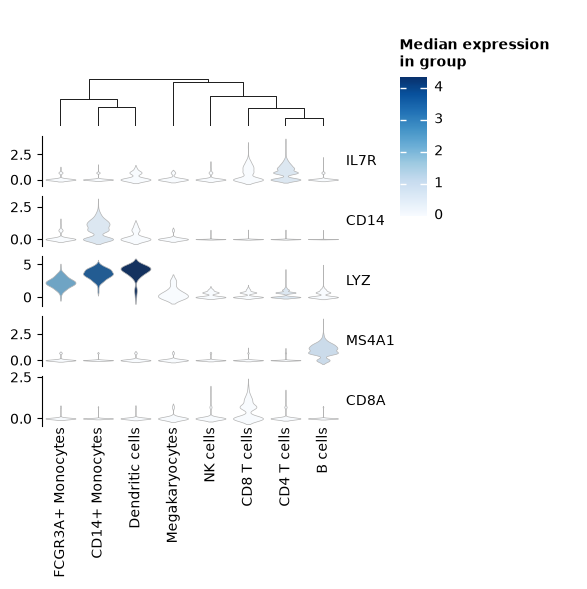

In [19]:
from legendkit import ColorArt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

sv_genes = markers[:5]
medians = pd.DataFrame({gene: by_cell_type(gene).median() for gene in sv_genes}).T
sm = ScalarMappable(
    norm=Normalize(medians.to_numpy().min(), medians.to_numpy().max()), cmap="Blues"
)

sv = ma.ClusterBoard(
    agg, A.layers["mean"][:, :], obs_axis="col", width=3, height=0, init_main=False
)

for gene in sv_genes:
    pdata = by_cell_type(gene)
    sv.add_bottom(
        mp.Violin(
            pdata,
            inner=None,
            linecolor=".7",
            linewidth=0.5,
            density_norm="width",
            palette=sm.to_rgba(pdata.median()).tolist(),
            label=gene,
            label_loc="right",
        ),
        size=0.5,
        pad=0.1,
        legend=False,
    )

sv.add_bottom(mp.Labels(A.obs.index))
sv.add_dendrogram("top")

sv.custom_legend(lambda: ColorArt(sm, title="Median expression\nin group"))
sv.add_legends(pad=0.3)
sv.render();

## More information

You can also write your own plotter.
[Marsilea's documentation shows how](https://marsilea.readthedocs.io/en/stable/tutorial/new_renderplan.html).

The same references work on a [MuData](https://mudata.readthedocs.io/): import `A` from
`mudata.acc` and reach into a modality with `A.mod["rna"].X[:, :]`. Modalities share the
`obs` axis, so plots from different modalities line up on the rows with no reindexing.
[Marsilea's AnnData and MuData
tutorial](https://marsilea.readthedocs.io/en/stable/tutorial/anndata.html) covers both.

In [20]:
sc.logging.print_header()

Package,Version
pandas,3.0.5
anndata,0.13.2
numpy,2.5.2
scanpy,1.14.0.dev31+g532d7b14c
marsilea,0.8.1
scipy,1.18.0
legendkit,0.5.1
matplotlib,3.11.1
Component,Info
Python,"3.13.1 (main, Jan 14 2025, 23:31:50) [Clang 19.1.6 ]"
